# 📱 Liquidity Stress Prediction Challenge - Starter Notebook

Welcome to the starter notebook for this challenge.

In this challenge, your goal is to build a machine learning model that predicts whether a customer is likely to experience liquidity stress, using historical mobile money behaviour.

This notebook walks through a simple end-to-end pipeline:

- Loading and exploring the data
- Preprocessing
- Training a baseline model
- Evaluating performance
- Generating predictions for submission

The baseline model used here is **Logistic Regression**, which is a good starting point for tabular classification problems.


In [1]:
# 📚 Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)


In [2]:
# 📥 Load the Data
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

SUBMISSION_TARGET = "Target"

# Create a sample submission template directly from the test IDs
sample_submission = pd.DataFrame({
    "ID": test["ID"],
    SUBMISSION_TARGET: 0.5
})

# Peek at the data
train.head()


,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

## 🔍 Exploratory Data Analysis (EDA)

Let’s explore the training data to understand the features and target.


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 184 entries, arpu to ID
dtypes: float64(134), int64(44), object(6)
memory usage: 56.2+ MB


In [4]:
train[train.isna().any(axis=1)]

,arpu,age,gender,region,smartphone,segment,earning_pattern,x_90_d_activity_rate,m1_paybill_volume,m1_paybill_total_value,m1_paybill_highest_amount,m1_paybill_companies,m2_paybill_volume,m2_paybill_total_value,m2_paybill_highest_amount,m2_paybill_companies,m3_paybill_volume,m3_paybill_total_value,m3_paybill_highest_amount,m3_paybill_companies,m4_paybill_volume,m4_paybill_total_value,m4_paybill_highest_amount,m4_paybill_companies,m5_paybill_volume,m5_paybill_total_value,m5_paybill_highest_amount,m5_paybill_companies,m6_paybill_volume,m6_paybill_total_value,m6_paybill_highest_amount,m6_paybill_companies,m1_merchantpay_volume,m1_merchantpay_total_value,m1_merchantpay_highest_amount,m1_merchantpay_merchants,m2_merchantpay_volume,m2_merchantpay_total_value,m2_merchantpay_highest_amount,m2_merchantpay_merchants,m3_merchantpay_volume,m3_merchantpay_total_value,m3_merchantpay_highest_amount,m3_merchantpay_merchants,m4_merchantpay_volume,m4_merchantpay_total_value,m4_merchantpay_highest_amount,m4_merchantpay_merchants,m5_merchantpay_volume,m5_merchantpay_total_value,m5_merchantpay_highest_amount,m5_merchantpay_merchants,m6_merchantpay_volume,m6_merchantpay_total_value,m6_merchantpay_highest_amount,m6_merchantpay_merchants,m1_transfer_from_bank_volume,m1_transfer_from_bank_total_value,m1_transfer_from_bank_highest_amount,m1_transfer_from_bank_banks,m2_transfer_from_bank_volume,m2_transfer_from_bank_total_value,m2_transfer_from_bank_highest_amount,m2_transfer_from_bank_banks,m3_transfer_from_bank_volume,m3_transfer_from_bank_total_value,m3_transfer_from_bank_highest_amount,m3_transfer_from_bank_banks,m4_transfer_from_bank_volume,m4_transfer_from_bank_total_value,m4_transfer_from_bank_highest_amount,m4_transfer_from_bank_banks,m5_transfer_from_bank_volume,m5_transfer_from_bank_total_value,m5_transfer_from_bank_highest_amount,m5_transfer_from_bank_banks,m6_transfer_from_bank_volume,m6_transfer_from_bank_total_value,m6_transfer_from_bank_highest_amount,m6_transfer_from_bank_banks,m1_mm_send_volume,m1_mm_send_total_value,m1_mm_send_highest_amount,m1_mm_send_recipients,m2_mm_send_volume,m2_mm_send_total_value,m2_mm_send_highest_amount,m2_mm_send_recipients,m3_mm_send_volume,m3_mm_send_total_value,m3_mm_send_highest_amount,m3_mm_send_recipients,m4_mm_send_volume,m4_mm_send_total_value,m4_mm_send_highest_amount,m4_mm_send_recipients,m5_mm_send_volume,m5_mm_send_total_value,m5_mm_send_highest_amount,m5_mm_send_recipients,m6_mm_send_volume,m6_mm_send_total_value,m6_mm_send_highest_amount,m6_mm_send_recipients,m1_received_volume,m1_received_total_value,m1_received_highest_amount,m1_received_senders,m2_received_volume,m2_received_total_value,m2_received_highest_amount,m2_received_senders,m3_received_volume,m3_received_total_value,m3_received_highest_amount,m3_received_senders,m4_received_volume,m4_received_total_value,m4_received_highest_amount,m4_received_senders,m5_received_volume,m5_received_total_value,m5_received_highest_amount,m5_received_senders,m6_received_volume,m6_received_total_value,m6_received_highest_amount,m6_received_senders,m1_deposit_volume,m1_deposit_total_value,m1_deposit_highest_amount,m1_deposit_agents,m2_deposit_volume,m2_deposit_total_value,m2_deposit_highest_amount,m2_deposit_agents,m3_deposit_volume,m3_deposit_total_value,m3_deposit_highest_amount,m3_deposit_agents,m4_deposit_volume,m4_deposit_total_value,m4_deposit_highest_amount,m4_deposit_agents,m5_deposit_volume,m5_deposit_total_value,m5_deposit_highest_amount,m5_deposit_agents,m6_deposit_volume,m6_deposit_total_value,m6_deposit_highest_amount,m6_deposit_agents,m1_withdraw_volume,m1_withdraw_total_value,m1_withdraw_highest_amount,m1_withdraw_agents,m2_withdraw_volume,m2_withdraw_total_value,m2_withdraw_highest_amount,m2_withdraw_agents,m3_withdraw_volume,m3_withdraw_total_value,m3_withdraw_highest_amount,m3_withdraw_agents,m4_withdraw_volume,m4_withdraw_total_value,m4_withdraw_highest_amount,m4_withdraw_agents,m5_withdraw_volume,m5_withdraw_total_value,m5_withdraw_highe

In [5]:
train.dtypes

arpu                         float64
age                            int64
gender                        object
region                        object
smartphone                    object
                              ...   
m4_daily_avg_bal             float64
m5_daily_avg_bal             float64
m6_daily_avg_bal             float64
liquidity_stress_next_30d      int64
ID                            object
Length: 184, dtype: object

In [6]:
# Check missing values
missing_summary = train.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].head(20)


Series([], dtype: int64)

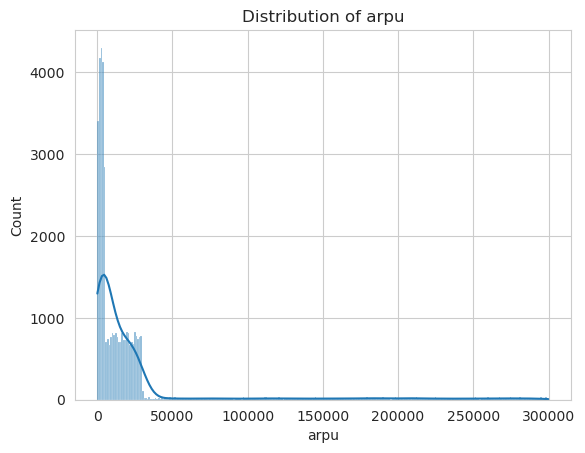

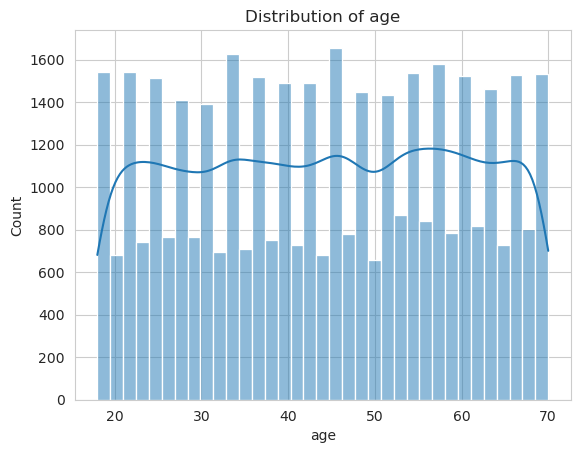

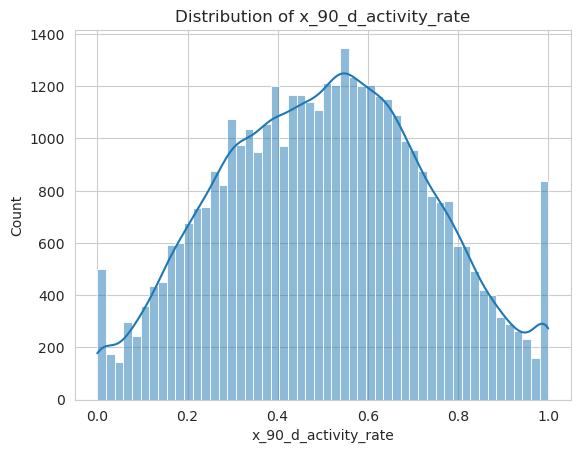

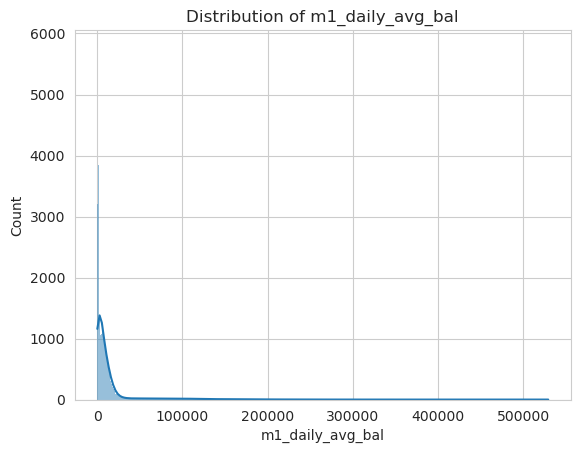

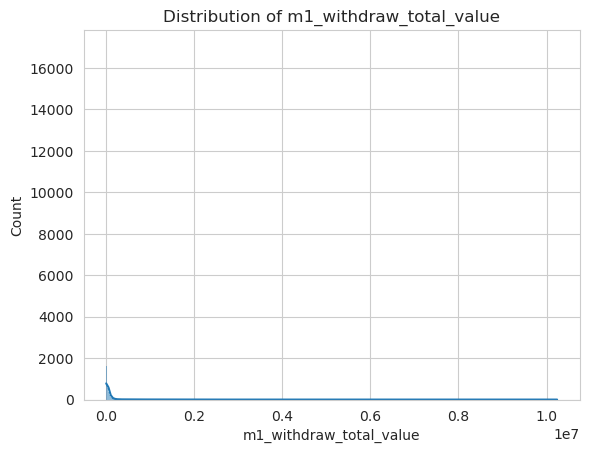

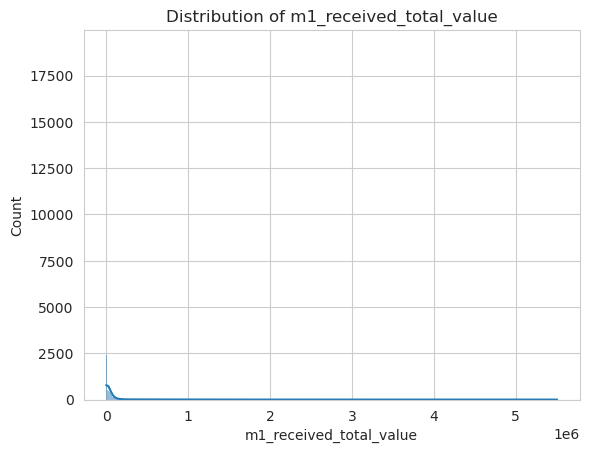

In [7]:
# Plot distributions of a few useful numeric features
num_features = [
    "arpu",
    "age",
    "x_90_d_activity_rate",
    "m1_daily_avg_bal",
    "m1_withdraw_total_value",
    "m1_received_total_value"
]

for col in num_features:
    if col in train.columns:
        sns.histplot(train[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()


In [ ]:
TARGET = "liquidity_stress_next_30d"

In [9]:
# Distribution of target variable
ax = sns.countplot(x=TARGET, data=train)
plt.title("Liquidity Stress Distribution")
plt.xlabel("Liquidity Stress (Next 30 Days)")
plt.ylabel("Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()


ValueError: Could not interpret value `liquidity_stress_next_30d	` for `x`. An entry with this name does not appear in `data`.

### 🏷️ Encoding Categorical Variables

We use **one-hot encoding** to convert categorical columns into numeric format so they can be used by the model.


In [10]:
# Identify the ID column, target column and feature columns
TARGET = "liquidity_stress_next_30d"
ID_COL = "ID"

feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET]]
cat_cols = train[feature_cols].select_dtypes(include="object").columns.tolist()
num_cols = train[feature_cols].select_dtypes(include=["float64", "int64"]).columns.tolist()



In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)
model_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=30,
            criterion="entropy",
            class_weight=None,
            min_samples_leaf=50,
            min_samples_split=10,
            max_features="sqrt",
            oob_score=True,
            random_state=42,
            n_jobs=-1
            ))
    ]
)
model_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'region',
                                                   'smartphone', 'segment',
                                                   'earning_pattern']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())])...
                                                   'm6_paybill_volume',
                                                   'm6_paybill_total_value',
                                                   'm6_paybill_highest_amount',
                                                   'm6_paybill_companies',
                                                   'm1_merchantpay_volume',
                                                   'm1_merchantpay_total_value',
                                                   'm1_merchantpay_highest_amount', ...])])),
                ('model',
                 RandomForestClassifier(criterion='entropy', max_depth=30,
                                        min_samples_leaf=50,
                                        min_samples_split=10, n_estimators=500,
                                        n_jobs=-1, oob_score=True,
                                        random_state=42))])

In [12]:
X = train[feature_cols]
y = train[TARGET]

In [13]:
splitter = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.3,
    random_state=42
)
splitter

StratifiedShuffleSplit(n_splits=5, random_state=42, test_size=0.3,
            train_size=None)

In [14]:
train_idx, val_idx = next(splitter.split(X, y))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


In [15]:
model_pipeline.fit(X_train, y_train)
val_pred_prob = model_pipeline.predict_proba(X_val)[:,1]
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))

Validation ROC-AUC: 0.7925318082788672


In [17]:
# Predict on validation set
from sklearn.metrics import log_loss
val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
print("Validation ROC-AUC:", roc_auc_score(y_val, val_pred_prob))
print("Validation Log Loss:", log_loss(y_val, val_pred_prob))
print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


Validation ROC-AUC: 0.7925318082788672
Validation Log Loss: 0.3616898729195111

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     10200
           1       0.94      0.04      0.08      1800

    accuracy                           0.86     12000
   macro avg       0.90      0.52      0.50     12000
weighted avg       0.87      0.86      0.80     12000



## 🧹 Preprocessing

We’ll split the training data into features and target, then create a validation set.


## 🤖 Model Training

We’ll use a Logistic Regression classifier as our baseline model.


In [18]:
def evaluation_metrics(y_val, val_pred_prob):
    val_log_loss = log_loss(y_val, val_pred_prob)
    val_roc_auc = roc_auc_score(y_val, val_pred_prob)
    combined_score = 0.6 * (1 - val_log_loss) + 0.4 * val_roc_auc   # higher = better
    return {
        "Validation Log Loss": val_log_loss,
        "Validation ROC-AUC": val_roc_auc,
        "Combined Score": combined_score
    }

In [19]:

# Predict on validation set
val_pred_prob = model_pipeline.predict_proba(X_val)[:, 1]
val_pred_label = (val_pred_prob >= 0.5).astype(int)

# Evaluate
val_evaluation = evaluation_metrics(y_val, val_pred_prob)
for name, value in val_evaluation.items():
    print(f"{name}: {value}")

print("\nClassification Report:")
print(classification_report(y_val, val_pred_label))


NameError: name 'log_loss' is not defined

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, log_loss, roc_auc_score
from scipy.stats import randint

def combined_score(y_true, y_pred_proba):
    ll = log_loss(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    return 0.6 * (1 - ll) + 0.4 * auc

combined_scorer = make_scorer(combined_score, response_method="predict_proba", greater_is_better=True)

rf_param_dist = {
    "model__n_estimators": [200, 300, 500],       # fewer trees during search = faster; bump up for final model
    "model__max_depth": [10, 15, 20, 30, None],
    "model__min_samples_leaf": randint(5, 100),     # smoothing/calibration knob (matters a lot for Log Loss)
    "model__min_samples_split": randint(2, 50),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5],
    "model__class_weight": ["balanced_subsample", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    estimator=model_pipeline,   # swap in your RF-based pipeline
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV Combined Score:", rf_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__class_weight': None, 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 28, 'model__min_samples_split': 4, 'model__n_estimators': 300}
Best CV Combined Score: 0.7314211853720544


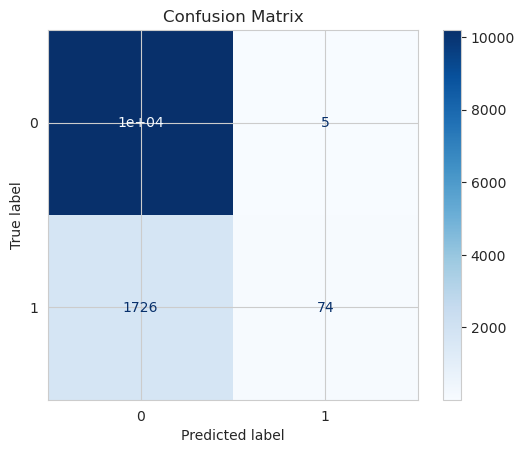

In [21]:
# 📈 Evaluate Model on Validation Set
cm = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


### Attempt cross-validation to find best hyper-parameters for logistic regression

In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, log_loss, roc_auc_score

def combined_score(y_true, y_pred_proba):
    ll = log_loss(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    return 0.6 * (1 - ll) + 0.4 * auc

In [ ]:
# NOTE: This was originally a Logistic Regression tuning experiment (solver/l1_ratio params),
# but model_pipeline now uses a RandomForestClassifier, so the set_params(solver=...) call
# below no longer applies and is skipped. random_search is left unused (rf_search is what
# gets used for the final model).
parameters = {
    "model__C": [0.01, 1, 10],
    "model__l1_ratio": np.arange(0, 1.01, 0.25).tolist(),
    "model__class_weight": ["balanced", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

combined_scorer = make_scorer(combined_score, response_method="predict_proba", greater_is_better=True)

random_search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=parameters,
    n_iter=5,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

"""
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    scoring=combined_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)
"""

In [24]:
rf_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['gender',
                                                                                'region',
                                                                                'smartphone',
                                                                                'segment',
                                                                                'earning_pattern']),
                                                                              ('num',
                                                                               P...
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.3, 0.5],
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x77e062c2d310>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x77e068552c60>,
                                        'model__n_estimators': [200, 300, 500]},
                   random_state=42,
                   scoring=make_scorer(combined_score, response_method='predict_proba'),
                   verbose=1)

In [25]:
print("Best params:", rf_search.best_params_)
print("Best CV Combined Score:", rf_search.best_score_)

best_model = rf_search.best_estimator_
val_pred_prob = best_model.predict_proba(X_val)[:, 1]

val_evaluation = evaluation_metrics(y_val, val_pred_prob)
for name, value in val_evaluation.items():
    print(f"{name}: {value}")

Best params: {'model__class_weight': None, 'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_leaf': 28, 'model__min_samples_split': 4, 'model__n_estimators': 300}
Best CV Combined Score: 0.7314211853720546
Validation Log Loss: 0.33155875046585787
Validation ROC-AUC: 0.8333501633986928
Combined Score: 0.7344048150799624


## 📊 Optional: Feature Importance

This section gives a quick sense of which features are most useful to the baseline model. It is optional and can be skipped if you only want to generate a first submission quickly.


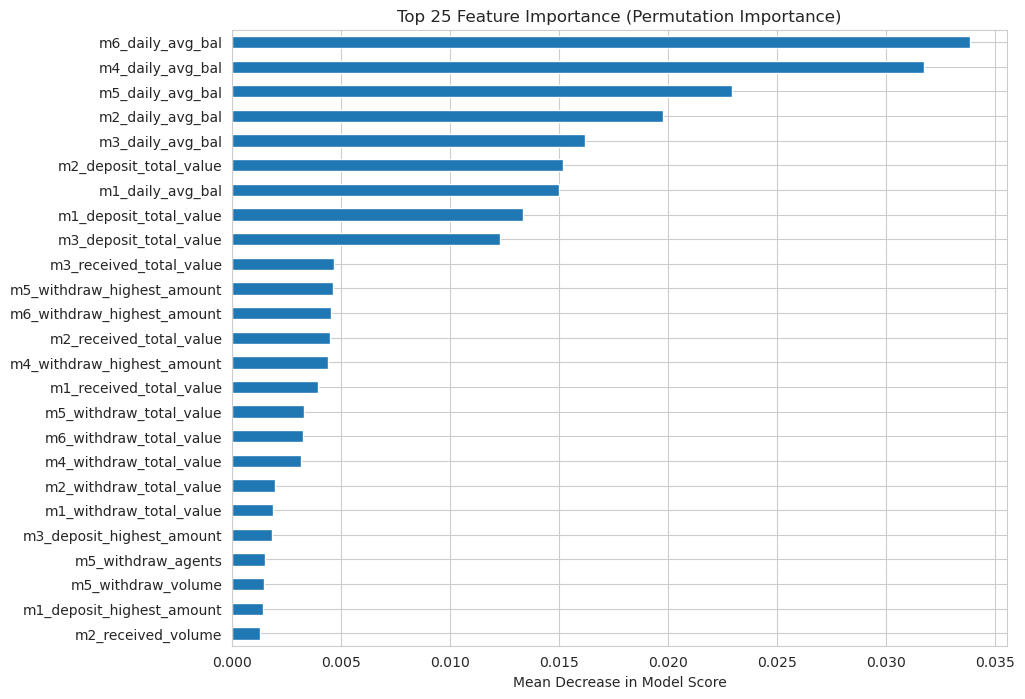

In [26]:
from sklearn.inspection import permutation_importance


result = permutation_importance(
    rf_search,
    X_val,
    y_val,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(result.importances_mean, index=X.columns)

(
    importances
    .sort_values(ascending=False)
    .head(25)
    .sort_values()
    .plot(kind="barh", figsize=(10,8))
)

plt.title("Top 25 Feature Importance (Permutation Importance)")
plt.xlabel("Mean Decrease in Model Score")
plt.show()


## 🚀 Predictions on Test Set

Let’s predict on the test set and generate a submission file.

The submission file must contain two columns:

- `ID`: the customer ID from the test set
- `Target`: the predicted probability that the customer will experience liquidity stress in the next 30 days

`Target` should be a probability between 0 and 1, not a hard class label.


In [27]:
# Retrain the model on the full training set
rf_search.best_estimator_.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'region',
                                                   'smartphone', 'segment',
                                                   'earning_pattern']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())])...
                                                   'm6_paybill_volume',
                                                   'm6_paybill_total_value',
                                                   'm6_paybill_highest_amount',
                                                   'm6_paybill_companies',
                                                   'm1_merchantpay_volume',
                                                   'm1_merchantpay_total_value',
                                                   'm1_merchantpay_highest_amount', ...])])),
                ('model',
                 RandomForestClassifier(criterion='entropy', max_features=0.5,
                                        min_samples_leaf=28,
                                        min_samples_split=4, n_estimators=300,
                                        n_jobs=-1, oob_score=True,
                                        random_state=42))])

In [ ]:
import pickle

# Save the best performing RF model (rf_search.best_estimator_) to disk
with open("rf_model.p", "wb") as f:
    pickle.dump(rf_search.best_estimator_, f)

print("Best RF model saved to rf_model.p")

In [ ]:
# Load the saved model back from disk and predict probabilities on test data
with open("rf_model.p", "rb") as f:
    rf_model = pickle.load(f)

test_predictions = rf_model.predict_proba(test[feature_cols])[:, 1]

In [29]:
# Prepare submission
submission = sample_submission.copy()
submission[SUBMISSION_TARGET] = test_predictions

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

submission.head()


Submission file saved!


,ID,Target
0,ID_ED91AC7A28,0.064591
1,ID_29975A9C7E,0.059840
2,ID_F59CE25650,0.069159
3,ID_E875F68D1A,0.027977
4,ID_2902B1C0D0,0.033628


## ✅ What’s Next?

This is just a baseline model. You are welcome to improve upon it or design your own pipeline from scratch!

Good luck, and happy modelling! 🚀
